<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-3-Holonomic-Mechanics/Untitled148.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Recovering Metric on a Sphere**

We present an implementation of the \emph{encoder-free recovery of a Riemannian metric}
on the unit sphere, defined by the holonomic constraint
$$
f(q) = q_1^2 + q_2^2 + q_3^2 - 1 = 0 .
$$
Since the gradient of the constraint spans the normal direction at each point,
$$
\nabla f(q) = 2q,
$$
the tangent space at a point $q \in S^2$ is given by
$$
T_q S^2 = \{\, v \in \mathbb{R}^3 \;:\; q^\top v = 0 \,\}.
$$

Our objective is to learn two orthonormal tangent vector fields
$B^1(q)$ and $B^2(q)$ satisfying
$$
q^\top B^j(q) = 0,
\qquad
B(q)^\top B(q) = I_2,
$$
where
$$
B(q) = \bigl[\, B^1(q)\; B^2(q) \,\bigr] \in \mathbb{R}^{3 \times 2}.
$$

Epoch 500: loss = 3.654e-02
Epoch 1000: loss = 2.009e-02
Epoch 1500: loss = 1.227e-02
Epoch 2000: loss = 4.040e-03


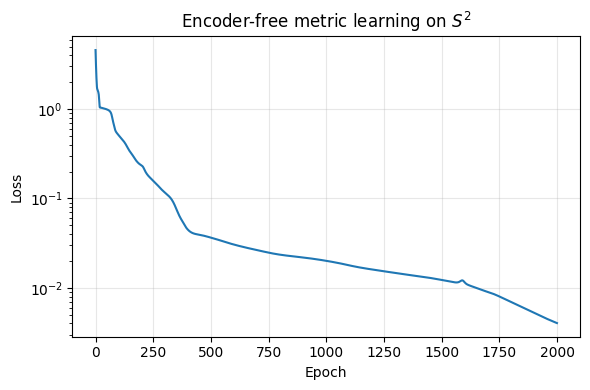

/tmp/ipython-input-2510911696.py:110: RuntimeWarning: invalid value encountered in sqrt
  ZZ = np.sqrt(1.0 - XX**2 - YY**2)


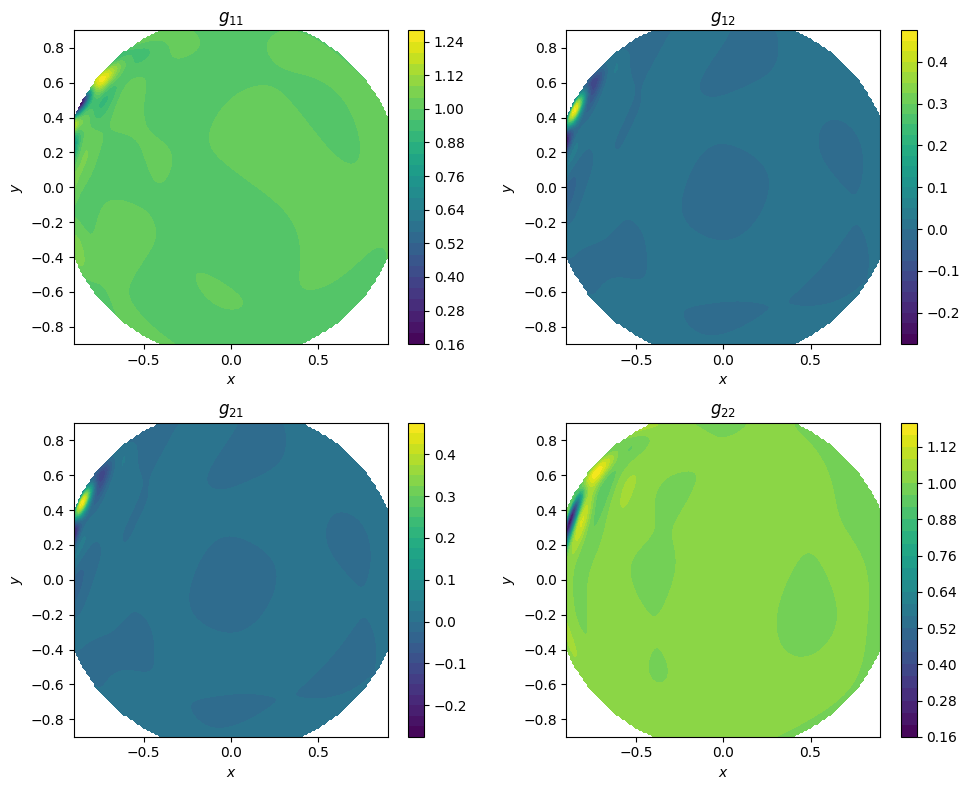

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ============================================================
# Encoder-free metric learning on the unit sphere S^2
# f(q) = ||q||^2 - 1 = 0,  grad f(q) = 2 q
# Learn B_theta(q) in R^{3x2} with:
#   q^T B = 0    (tangency)
#   B^T B = I_2  (orthonormality)
# ============================================================

np.random.seed(0)
tf.random.set_seed(0)

# ------------------------------------------------------------
# 1) Sample points on the unit sphere
# ------------------------------------------------------------
N = 2000

phi = np.random.uniform(0, 2*np.pi, N)
costheta = np.random.uniform(-1.0, 1.0, N)
theta = np.arccos(costheta)

x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)

q_data = np.stack([x, y, z], axis=1).astype(np.float32)
q_tf = tf.constant(q_data)

# ------------------------------------------------------------
# 2) Constraint gradient
# ------------------------------------------------------------
def grad_f(q):
    return 2.0 * q  # shape (N,3)

# ------------------------------------------------------------
# 3) Network B_theta(q): R^3 -> R^{3x2}
# ------------------------------------------------------------
def build_B_net():
    return keras.Sequential([
        layers.Input(shape=(3,)),
        layers.Dense(64, activation="swish"),
        layers.Dense(64, activation="swish"),
        layers.Dense(6)  # 3x2 entries
    ])

B_net = build_B_net()
optimizer = keras.optimizers.Adam(1e-3)

# ------------------------------------------------------------
# 4) Training loop
# ------------------------------------------------------------
mu = 10.0
EPOCHS = 2000
loss_hist = []

dataset = tf.data.Dataset.from_tensor_slices(q_tf).batch(256)

for epoch in range(EPOCHS):
    for q_batch in dataset:
        with tf.GradientTape() as tape:
            B_flat = B_net(q_batch)                # (batch,6)
            B = tf.reshape(B_flat, (-1, 3, 2))    # (batch,3,2)

            # Tangency: q^T B = 0
            grad = grad_f(q_batch)[:, :, None]    # (batch,3,1)
            tangency = tf.matmul(grad, B, transpose_a=True)  # (batch,1,2)
            loss_tan = tf.reduce_mean(tf.square(tangency))

            # Orthonormality: B^T B = I
            BTB = tf.matmul(B, B, transpose_a=True)  # (batch,2,2)
            I = tf.eye(2, batch_shape=[tf.shape(BTB)[0]])
            loss_ortho = tf.reduce_mean(tf.square(BTB - I))

            loss = loss_tan + mu * loss_ortho

        grads = tape.gradient(loss, B_net.trainable_variables)
        optimizer.apply_gradients(zip(grads, B_net.trainable_variables))

    loss_hist.append(loss.numpy())
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: loss = {loss_hist[-1]:.3e}")

# ------------------------------------------------------------
# 5) Plot loss vs epochs
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(loss_hist)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Encoder-free metric learning on $S^2$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) Evaluate metric coefficients on a chart (x,y) with z>0
# ------------------------------------------------------------
grid = 150
xx = np.linspace(-0.9, 0.9, grid)
yy = np.linspace(-0.9, 0.9, grid)
XX, YY = np.meshgrid(xx, yy)

mask = XX**2 + YY**2 < 0.98
ZZ = np.sqrt(1.0 - XX**2 - YY**2)
ZZ[~mask] = np.nan

Q = np.stack([XX, YY, ZZ], axis=-1)
Q_flat = Q.reshape(-1,3).astype(np.float32)

B_flat = B_net(Q_flat)
B = B_flat.numpy().reshape(-1,3,2)

g11 = np.sum(B[:,:,0]*B[:,:,0], axis=1).reshape(grid,grid)
g12 = np.sum(B[:,:,0]*B[:,:,1], axis=1).reshape(grid,grid)
g21 = np.sum(B[:,:,1]*B[:,:,0], axis=1).reshape(grid,grid)
g22 = np.sum(B[:,:,1]*B[:,:,1], axis=1).reshape(grid,grid)

# ------------------------------------------------------------
# 7) Contour plots of metric coefficients
# ------------------------------------------------------------
fig, axs = plt.subplots(2,2, figsize=(10,8))

cs = axs[0,0].contourf(XX, YY, g11, 30)
axs[0,0].set_title(r"$g_{11}$")
plt.colorbar(cs, ax=axs[0,0])

cs = axs[0,1].contourf(XX, YY, g12, 30)
axs[0,1].set_title(r"$g_{12}$")
plt.colorbar(cs, ax=axs[0,1])

cs = axs[1,0].contourf(XX, YY, g21, 30)
axs[1,0].set_title(r"$g_{21}$")
plt.colorbar(cs, ax=axs[1,0])

cs = axs[1,1].contourf(XX, YY, g22, 30)
axs[1,1].set_title(r"$g_{22}$")
plt.colorbar(cs, ax=axs[1,1])

for ax in axs.flat:
    ax.set_aspect("equal")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

plt.tight_layout()
plt.show()


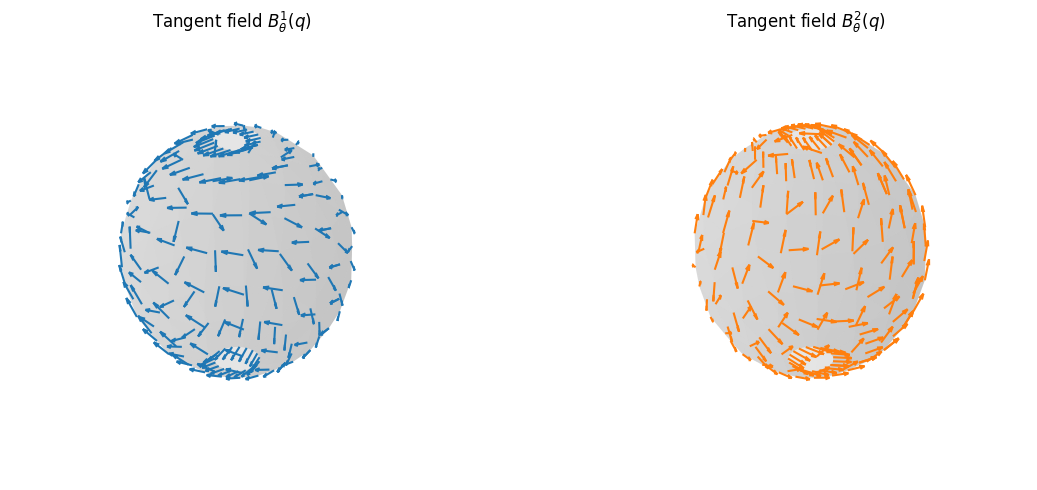

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Sample points on the sphere (regular grid for visualization)
# ------------------------------------------------------------
n_theta = 10
n_phi = 20

theta = np.linspace(0.2, np.pi-0.2, n_theta)   # avoid poles
phi = np.linspace(0, 2*np.pi, n_phi)

TH, PH = np.meshgrid(theta, phi)

X = np.sin(TH)*np.cos(PH)
Y = np.sin(TH)*np.sin(PH)
Z = np.cos(TH)

Q = np.stack([X, Y, Z], axis=-1).reshape(-1,3).astype(np.float32)

# ------------------------------------------------------------
# 2) Evaluate learned tangent frame B_theta(q)
# ------------------------------------------------------------
B_flat = B_net(Q)
B = B_flat.numpy().reshape(-1,3,2)

B1 = B[:,:,0]   # first tangent field
B2 = B[:,:,1]   # second tangent field

# Normalize for clean arrows (numerical safety)
B1 /= np.linalg.norm(B1, axis=1, keepdims=True)
B2 /= np.linalg.norm(B2, axis=1, keepdims=True)

# Reshape back to grid
Xg, Yg, Zg = X.reshape(-1), Y.reshape(-1), Z.reshape(-1)

B1x, B1y, B1z = B1[:,0], B1[:,1], B1[:,2]
B2x, B2y, B2z = B2[:,0], B2[:,1], B2[:,2]

# ------------------------------------------------------------
# 3) Plot sphere + vector fields
# ------------------------------------------------------------
fig = plt.figure(figsize=(12,5))

# ---- B^1 field ----
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, Y, Z, alpha=0.15, color="gray", linewidth=0)
ax1.quiver(Xg, Yg, Zg, B1x, B1y, B1z,
           length=0.18, normalize=True, color="tab:blue")
ax1.set_title(r"Tangent field $B^1_\theta(q)$")
ax1.set_box_aspect([1,1,1])
ax1.set_axis_off()

# ---- B^2 field ----
ax2 = fig.add_subplot(122, projection="3d")
ax2.plot_surface(X, Y, Z, alpha=0.15, color="gray", linewidth=0)
ax2.quiver(Xg, Yg, Zg, B2x, B2y, B2z,
           length=0.18, normalize=True, color="tab:orange")
ax2.set_title(r"Tangent field $B^2_\theta(q)$")
ax2.set_box_aspect([1,1,1])
ax2.set_axis_off()

plt.tight_layout()
plt.show()


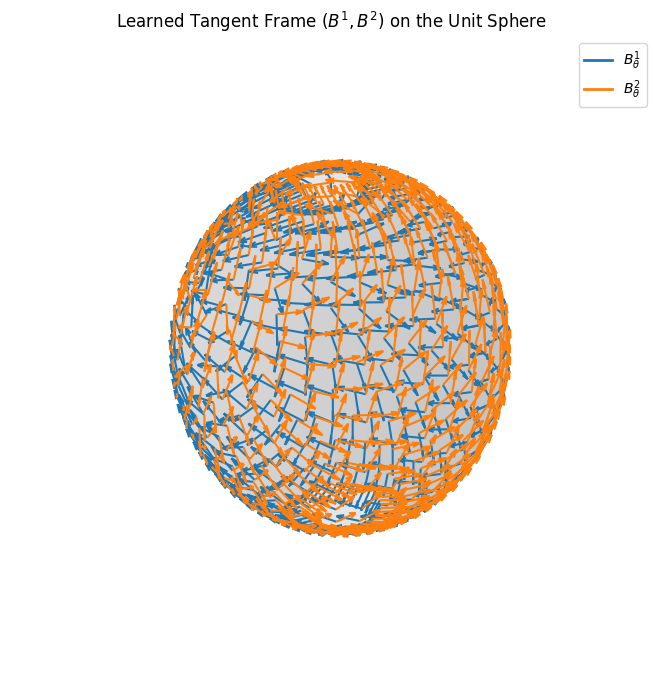

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Sample points on the unit sphere (avoid poles)
# ------------------------------------------------------------
n_theta = 18
n_phi = 36

theta = np.linspace(0.25, np.pi-0.25, n_theta)
phi = np.linspace(0, 2*np.pi, n_phi)

TH, PH = np.meshgrid(theta, phi)

X = np.sin(TH)*np.cos(PH)
Y = np.sin(TH)*np.sin(PH)
Z = np.cos(TH)

Q = np.stack([X, Y, Z], axis=-1).reshape(-1,3).astype(np.float32)

# ------------------------------------------------------------
# 2) Evaluate learned tangent frame B_theta(q)
# ------------------------------------------------------------
B_flat = B_net(Q)
B = B_flat.numpy().reshape(-1,3,2)

B1 = B[:,:,0]
B2 = B[:,:,1]

# Normalize for clean arrows
B1 /= np.linalg.norm(B1, axis=1, keepdims=True)
B2 /= np.linalg.norm(B2, axis=1, keepdims=True)

Xg, Yg, Zg = Q[:,0], Q[:,1], Q[:,2]

# ------------------------------------------------------------
# 3) Plot sphere + both tangent vectors at each point
# ------------------------------------------------------------
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection="3d")

# Sphere
ax.plot_surface(X, Y, Z, alpha=0.15, color="gray", linewidth=0)

# B^1 vectors (blue)
ax.quiver(Xg, Yg, Zg,
          B1[:,0], B1[:,1], B1[:,2],
          length=0.18, normalize=True, color="tab:blue",
          label=r"$B^1_\theta$")

# B^2 vectors (orange)
ax.quiver(Xg, Yg, Zg,
          B2[:,0], B2[:,1], B2[:,2],
          length=0.18, normalize=True, color="tab:orange",
          label=r"$B^2_\theta$")

ax.set_title("Learned Tangent Frame $(B^1,B^2)$ on the Unit Sphere")
ax.set_box_aspect([1,1,1])
ax.set_axis_off()

# Legend proxy (quiver has no automatic legend)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color="tab:blue", lw=2, label=r"$B^1_\theta$"),
    Line2D([0],[0], color="tab:orange", lw=2, label=r"$B^2_\theta$")
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()


# **Recovering Metric on a Torus**

Epoch 500/1400 | Loss 1.977e+00 | tan 1.58e+00 | ortho 3.93e-01
Epoch 1000/1400 | Loss 6.171e-01 | tan 2.92e-01 | ortho 3.26e-01


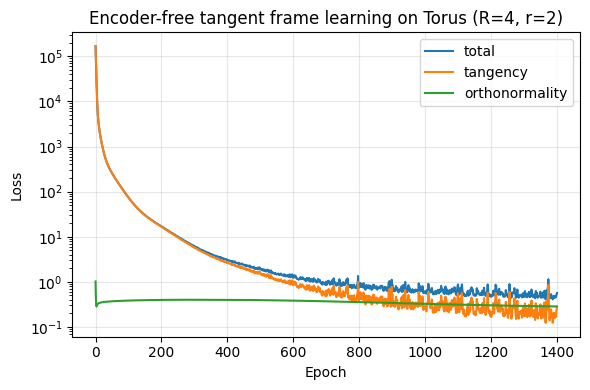

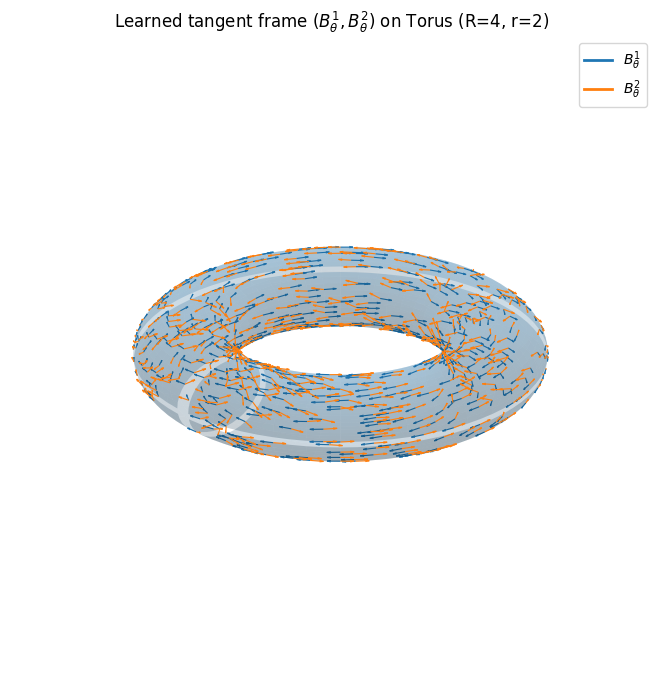

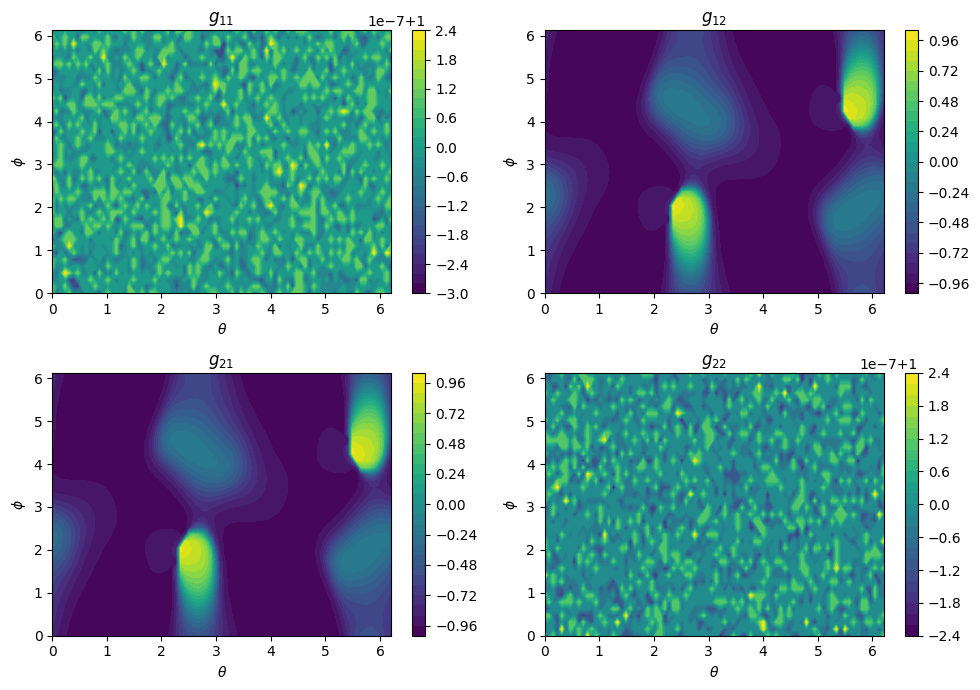

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ============================================================
# Encoder-free metric learning from the holonomic constraint
# for the torus with R=4, r=2.
#
# Implicit torus:
#   f(x,y,z) = (x^2+y^2+z^2 + R^2 - r^2)^2 - 4 R^2 (x^2+y^2) = 0
#
# Here n=3, k=1 -> d=n-k=2.
# Learn B_theta(q) in R^{3x2} with:
#   (∇f(q))^T B = 0      (tangency)
#   B^T B = I_2          (orthonormality)
# ============================================================

np.random.seed(0)
tf.random.set_seed(0)

# ----------------------------
# Torus parameters
# ----------------------------
R = 6.0
r = 2.0

# ----------------------------
# 1) Sample points on the torus (uniform in angles)
# ----------------------------
N = 4000
theta = np.random.uniform(0.0, 2*np.pi, N).astype(np.float32)  # around the big circle
phi   = np.random.uniform(0.0, 2*np.pi, N).astype(np.float32)  # around the tube

x = (R + r*np.cos(phi)) * np.cos(theta)
y = (R + r*np.cos(phi)) * np.sin(theta)
z = r * np.sin(phi)

q_data = np.stack([x, y, z], axis=1).astype(np.float32)
q_tf = tf.constant(q_data)

# ----------------------------
# 2) Constraint and gradient
# ----------------------------
def f_torus(q):
    # q: (batch,3)
    x, y, z = q[:,0], q[:,1], q[:,2]
    s = x*x + y*y + z*z + (R*R - r*r)
    return s*s - 4*(R*R)*(x*x + y*y)

def grad_f_torus(q):
    x, y, z = q[:,0], q[:,1], q[:,2]
    s = x*x + y*y + z*z + (R*R - r*r)
    # f = s^2 - 4R^2 (x^2+y^2)
    # df/dx = 2s*(2x) - 8R^2 x = 4x*s - 8R^2 x = 4x*(s - 2R^2)
    # df/dy = 4y*(s - 2R^2)
    # df/dz = 2s*(2z) = 4z*s
    gx = 4.0 * x * (s - 2.0*R*R)
    gy = 4.0 * y * (s - 2.0*R*R)
    gz = 4.0 * z * s
    return tf.stack([gx, gy, gz], axis=1)  # (batch,3)

# ----------------------------
# 3) Network B_theta(q): R^3 -> R^{3x2}
# ----------------------------
def build_B_net():
    return keras.Sequential([
        layers.Input(shape=(3,)),
        layers.Dense(64, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(6)  # 3x2 entries
    ])

B_net = build_B_net()
opt = keras.optimizers.Adam(1e-4)

# ----------------------------
# 4) Train with tangency + orthonormality loss
# ----------------------------
mu = 1.0
EPOCHS = 1400
batch_size = 250

loss_hist = []
loss_tan_hist = []
loss_ortho_hist = []

dataset = tf.data.Dataset.from_tensor_slices(q_tf).shuffle(5000).batch(batch_size)

for epoch in range(EPOCHS):
    epoch_loss = []
    epoch_lt = []
    epoch_lo = []

    for q_batch in dataset:
        with tf.GradientTape() as tape:
            B_flat = B_net(q_batch)                 # (batch,6)
            B = tf.reshape(B_flat, (-1, 3, 2))      # (batch,3,2)

            g = grad_f_torus(q_batch)[:, :, None]   # (batch,3,1)

            # Tangency: (∇f)^T B = 0   -> shape (batch,1,2)
            tang = tf.matmul(g, B, transpose_a=True)
            loss_tan = tf.reduce_mean(tf.square(tang))

            # Orthonormality: B^T B = I_2
            BTB = tf.matmul(B, B, transpose_a=True)  # (batch,2,2)
            I = tf.eye(2, batch_shape=[tf.shape(BTB)[0]])
            loss_ortho = tf.reduce_mean(tf.square(BTB - I))

            loss = loss_tan + mu * loss_ortho

        grads = tape.gradient(loss, B_net.trainable_variables)
        opt.apply_gradients(zip(grads, B_net.trainable_variables))

        epoch_loss.append(loss.numpy())
        epoch_lt.append(loss_tan.numpy())
        epoch_lo.append(loss_ortho.numpy())

    loss_hist.append(float(np.mean(epoch_loss)))
    loss_tan_hist.append(float(np.mean(epoch_lt)))
    loss_ortho_hist.append(float(np.mean(epoch_lo)))

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Loss {loss_hist[-1]:.3e} | "
              f"tan {loss_tan_hist[-1]:.2e} | "
              f"ortho {loss_ortho_hist[-1]:.2e}")

# ----------------------------
# 5) Plot loss curves
# ----------------------------
plt.figure(figsize=(6,4))
plt.plot(loss_hist, label="total")
plt.plot(loss_tan_hist, label="tangency")
plt.plot(loss_ortho_hist, label="orthonormality")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Encoder-free tangent frame learning on Torus (R=4, r=2)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6) Plot both vector fields B^1 and B^2 on the torus (colored pair)
#    (IMPROVED: correct aspect ratio, better view, less clutter)
# ============================================================

n_th = 80
n_ph = 40
TH, PH = np.meshgrid(
    np.linspace(0, 2*np.pi, n_th, endpoint=False),
    np.linspace(0, 2*np.pi, n_ph, endpoint=False),
)

X = (R + r*np.cos(PH)) * np.cos(TH)
Y = (R + r*np.cos(PH)) * np.sin(TH)
Z = r * np.sin(PH)

Q_vis = np.stack([X, Y, Z], axis=-1).reshape(-1, 3).astype(np.float32)
B_vis = B_net(Q_vis).numpy().reshape(-1, 3, 2)

B1 = B_vis[:, :, 0]
B2 = B_vis[:, :, 1]

# Normalize (numerical safety)
B1 /= np.linalg.norm(B1, axis=1, keepdims=True)
B2 /= np.linalg.norm(B2, axis=1, keepdims=True)

Xg, Yg, Zg = Q_vis[:, 0], Q_vis[:, 1], Q_vis[:, 2]

# ---- Subsample vectors to reduce clutter ----
np.random.seed(0)
num_arrows = 600  # tune: 300–900 looks good
idx = np.random.choice(len(Q_vis), size=num_arrows, replace=False)

# ---- Plot ----
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Surface
ax.plot_surface(X, Y, Z, alpha=0.22, linewidth=0)

# Shorter, thinner arrows (so the donut hole stays visible)
arrow_len = 0.50
ax.quiver(Xg[idx], Yg[idx], Zg[idx],
          B1[idx, 0], B1[idx, 1], B1[idx, 2],
          length=arrow_len, normalize=True, linewidth=0.8,
          color="tab:blue")

ax.quiver(Xg[idx], Yg[idx], Zg[idx],
          B2[idx, 0], B2[idx, 1], B2[idx, 2],
          length=arrow_len, normalize=True, linewidth=0.8,
          color="tab:orange")

# Donut-friendly view
ax.view_init(elev=25, azim=45)

# ---- Force true equal scaling in 3D (THIS is the key fix) ----
max_range = np.array([
    X.max() - X.min(),
    Y.max() - Y.min(),
    Z.max() - Z.min()
]).max() / 2.0

mid_x = 0.5 * (X.max() + X.min())
mid_y = 0.5 * (Y.max() + Y.min())
mid_z = 0.5 * (Z.max() + Z.min())

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.set_title(r"Learned tangent frame $(B^1_\theta,B^2_\theta)$ on Torus (R=4, r=2)")
ax.set_axis_off()

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color="tab:blue", lw=2, label=r"$B^1_\theta$"),
    Line2D([0], [0], color="tab:orange", lw=2, label=r"$B^2_\theta$")
], loc="upper right")

plt.tight_layout()
plt.show()


# ============================================================
# 7) Metric coefficients g_ab = <B^a, B^b> over (theta,phi)
#    Contour plots in the parameter domain (TH,PH).
# ============================================================

# Compute g on the same visualization grid
g11 = np.sum(B1*B1, axis=1).reshape(n_ph, n_th)
g12 = np.sum(B1*B2, axis=1).reshape(n_ph, n_th)
g21 = np.sum(B2*B1, axis=1).reshape(n_ph, n_th)
g22 = np.sum(B2*B2, axis=1).reshape(n_ph, n_th)

# Use theta-phi axes for contours
th_grid = TH
ph_grid = PH

fig, axs = plt.subplots(2,2, figsize=(10,7))

cs = axs[0,0].contourf(th_grid, ph_grid, g11, 30)
axs[0,0].set_title(r"$g_{11}$")
plt.colorbar(cs, ax=axs[0,0])

cs = axs[0,1].contourf(th_grid, ph_grid, g12, 30)
axs[0,1].set_title(r"$g_{12}$")
plt.colorbar(cs, ax=axs[0,1])

cs = axs[1,0].contourf(th_grid, ph_grid, g21, 30)
axs[1,0].set_title(r"$g_{21}$")
plt.colorbar(cs, ax=axs[1,0])

cs = axs[1,1].contourf(th_grid, ph_grid, g22, 30)
axs[1,1].set_title(r"$g_{22}$")
plt.colorbar(cs, ax=axs[1,1])

for ax in axs.flat:
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel(r"$\phi$")

plt.tight_layout()
plt.show()
